In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from qutip import *
# import rydsim
from math import * 
import pandas as pd 
from tqdm import tqdm 
from scipy import integrate 
import scipy.constants 
from scipy.constants import Planck,epsilon_0,Boltzmann
from scipy.optimize import curve_fit 
from lmfit import Model
from lmfit.models import GaussianModel, ConstantModel ,LorentzianModel ,LinearModel ,RectangleModel
from scipy import signal
# Define path to ARC root directory (for loading data)
import sys, os
# rootDir = 'd:\\Heidelberg\\Calculation\\Python\\arc_python27_v1_3\\arc\\' # e.g. '/Users/Username/Desktop/ARC-Alkali-Rydberg-Calculator'
# sys.path.append(rootDir)
# os.chdir(rootDir)

from arc import *                 #Import ARC (Alkali Rydberg Calculator)
atom = Rubidium85()

In [3]:
# States 2-photon, 32D5/2
[n1,l1,j1,mj1] = [5,0,0.5,0.5]  # 5S1/2, mj=1/2
[n2,l2,j2,mj2] = [5,1,1.5,0.5]  # 5P3/2, mj=1/2
[n3,l3,j3,mj3] = [32,0,0.5,0.5]  # 32S1/2, mj=1/2
[n4,l4,j4,mj4] = [32,1,1.5,0.5]  # 32P3/2, mj=1/2

# Beam power (W)
power12 = 10.e-9 # 10nW
power23 = 60.e-3 # 60mW
power34 = 10e-3 # 10mW

# Beam waist (m)
waist12 = (150.e-6)/2  
waist23 = (150.e-6)/2
waist34 = 0.02

# Transition wavelength (m)
lambda12 = atom.getTransitionWavelength(n1,l1,j1,n2,l2,j2) # 780-nm laser
lambda23 = atom.getTransitionWavelength(n2,l2,j2,n3,l3,j3) # 480-nm laser
lambda34 = atom.getTransitionWavelength(n3,l3,j3,n4,l4,j4) # RF

# Transition frequency (Hz)
freq12 = atom.getTransitionFrequency(n1,l1,j1,n2,l2,j2) # 780-nm laser
freq23 = atom.getTransitionFrequency(n2,l2,j2,n3,l3,j3) # 480-nm laser
freq34 = atom.getTransitionFrequency(n3,l3,j3,n4,l4,j4) # RF

# Dipole moment matrix element
q=0 # linear polarization
dipmat12 = atom.getDipoleMatrixElement(n1,l1,j1,mj1,n2,l2,j2,mj2,q)
dipmat23 = atom.getDipoleMatrixElement(n2,l2,j2,mj2,n3,l3,j3,mj3,q)
dipmat34 = atom.getDipoleMatrixElement(n3,l3,j3,mj3,n4,l4,j4,mj4,q)

# Transition detuning (Hz)
delta12 = 0
delta23 = 0
delta34 = 0

# Rabi Frequency (2pi is already included)
rabi12 = atom.getRabiFrequency(n1,l1,j1,mj1,n2,l2,j2,q,power12,waist12)/(2*pi)*1e-6 # unit of 2pi MHz
rabi23 = atom.getRabiFrequency(n2,l2,j2,mj2,n3,l3,j3,q,power23,waist23)/(2*pi)*1e-6 # unit of 2pi MHz
rabi34 = atom.getRabiFrequency(n3,l3,j3,mj2,n4,l4,j4,q,power34,waist34)/(2*pi)*1e-6 # unit of 2pi MHz

In [4]:
debug = 1
temperature = 300 # Room temperature: 300 Kelvin

n = [0 for i in range(4)]
l = [0 for i in range(4)]
j = [0 for i in range(4)]
mj = [0 for i in range(4)]
[n[0],l[0],j[0],mj[0]] = [5,0,0.5,0.5]  # 5S1/2, mj=1/2
[n[1],l[1],j[1],mj[1]] = [5,1,1.5,0.5]  # 5P3/2, mj=1/2
[n[2],l[2],j[2],mj[2]] = [32,0,0.5,0.5]  # 32S1/2, mj=1/2
[n[3],l[3],j[3],mj[3]] = [32,1,1.5,0.5]  # 32P3/2, mj=1/2

# Beam power (W)
power = [10.e-9,60.e-3,10e-3]

# Beam waist (m)
waist=[(150.e-6)/2,(150.e-6)/2,0.025]

# Wavelength (m)
lambda_trans = [atom.getTransitionWavelength(n[i],l[i],j[i],n[i+1],l[i+1],j[i+1]) for i in range(len(n)-1)]
if debug: print('Wavelength (m)',lambda_trans)

# Rabi Frequency (Hz)
Rabifreq = [atom.getRabiFrequency(n[i],l[i],j[i],mj[i],n[i+1],l[i+1],j[i+1],q,power[i],waist[i])/(2*pi) for i in range(len(n)-1)]
if debug: print('Rabi Frequency (Hz)',Rabifreq)

# Decay rate (Hz)
Gamma =[0]+ [1/atom.getStateLifetime(n[i],l[i],j[i],temperature=temperature,includeLevelsUpTo=n[i]+10)/(2*pi) for i in range(1,len(n))]
if debug: print('Gamma (Hz): ',Gamma)

# Different in transition frequency comparing to ground state (Hz)
def Hdiag(n,l,j):
    Estate = []
    statelist = []
    for i in range(len(n)):
        transition = atom.getTransitionFrequency(n[0],l[0],j[0],n[i],l[i],j[i])*2*pi        
        statelist.append([n[i],l[i],j[i]])
        Estate.append(transition)    
    nstate = len(Estate)
    Hstate = np.diag(Estate)
    return nstate, statelist, Hstate
if debug: print(Hdiag(n,l,j)[2])

Wavelength (m) [np.float64(7.802414762021273e-07), np.float64(4.82100139311448e-07), 0.002297133888579615]
Rabi Frequency (Hz) [np.float64(911940.821030698), np.float64(12574646.13352145), np.float64(509420590.15879244)]
Gamma (Hz):  [0, np.float64(6065897.833796889), np.float64(8520.89541325387), np.float64(5370.247723464842)]
[[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 2.41419051e+15 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 6.32136957e+15 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 6.32218957e+15]]


In [5]:
# Define the levels and atomic projection operators
one, two, three, four = [basis(4,i) for i in range(4)]

In [6]:
# Define the levels and atomic projection operators
sig_11 = one * one.dag()
sig_22 = two * two.dag()
sig_33 = three * three.dag() 
sig_44 = four * four.dag() 
sig_12 = one * two.dag()  
sig_13 = one * three.dag() 
sig_14 = one * four.dag() 
sig_23 = two * three.dag()  
sig_24 = two * four.dag()
sig_34 = three * four.dag()

In [7]:
gamma_diag = np.diag(Gamma);gamma_diag

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 6.06589783e+06, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 8.52089541e+03, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 5.37024772e+03]])

In [8]:
#define number of state 
n_state = int(4) 
gamma_off = [[np.float64(0.5 * (gamma_diag[i][i] + gamma_diag[j][j])) if i != j else np.float64(0) for j in range(n_state)] for i in range(n_state)]

In [9]:
gamma = (gamma_diag+gamma_off)*2*pi ;gamma

array([[0.00000000e+00, 1.90565801e+07, 2.67691824e+04, 1.68711308e+04],
       [1.90565801e+07, 3.81131601e+07, 1.90833493e+07, 1.90734512e+07],
       [2.67691824e+04, 1.90833493e+07, 5.35383649e+04, 4.36403132e+04],
       [1.68711308e+04, 1.90734512e+07, 4.36403132e+04, 3.37422616e+04]])

In [10]:
#collapse operators 
c_12 = -np.sqrt(gamma[0][1])*sig_12 # 1-2 coherence decay  
#c_21 = -np.sqrt(gamma[0][1])*sig_21
c_13 = -np.sqrt(gamma[0][2])*sig_13 # 1-3 coherence decay  
#c_31 = -np.sqrt(gamma[0][2])*sig_31 # 1-3 coherence decay  
c_14 = -np.sqrt(gamma[0][3])*sig_14  # 1-4 coherence decay  
#c_41 = -np.sqrt(gamma[0][3])*sig_41  # 1-4 coherence decay   
c_23 = -np.sqrt(gamma[1][2])*sig_23 # 2-3 coherence decay 
#c_32 = -np.sqrt(gamma[1][2])*sig_32 # 2-3 coherence decay 
c_24 = -np.sqrt(gamma[1][3])*sig_24  # 2-4 coherence decay  
#c_42 = -np.sqrt(gamma[1][3])*sig_42  # 2-4 coherence decay  
c_34 = -np.sqrt(gamma[2][3])*sig_34  
#c_43 = -np.sqrt(gamma[2][3])*sig_43
#transitions decay rate  
c_11 = np.sqrt(gamma[1][1])*sig_22
c_22 = np.sqrt(gamma[2][2])*sig_33 -  np.sqrt(gamma[1][1])*sig_22
c_33 = np.sqrt(gamma[3][3])*sig_44 -  np.sqrt(gamma[2][2])*sig_33
c_44 = -np.sqrt(gamma[3][3])*sig_44 
#check define collapse operator
collapse = [c_11,c_22,c_33,c_44,c_12,c_13,c_14,c_23,c_24,c_34]

In [11]:
debug = 1
temperature = 300 # Room temperature: 300 Kelvin
# Define bases for the n-level system
nlevel = 4
psi = [basis(nlevel,i) for i in range(nlevel)]
rho = [[psi[j]*psi[i].dag() for i in range(nlevel)] for j in range(nlevel)]
if debug: print(rho[1][2])

# Decay rate Gamma (Hz)
Gamma =[0]+ [1/atom.getStateLifetime(n[i],l[i],j[i],temperature=temperature,includeLevelsUpTo=n[i]+10)/(2*pi) for i in range(1,nlevel)]
if debug: print('Gamma (Hz): ',Gamma)

# Relaxation rate gamma (Hz)
gamma = np.array([[(Gamma[i]+Gamma[j])/2 for i in range(nlevel)] for j in range(nlevel)])
if debug: print('gamma (Hz): \n',gamma)

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Gamma (Hz):  [0, np.float64(6065897.833796889), np.float64(8520.89541325387), np.float64(5370.247723464842)]
gamma (Hz): 
 [[0.00000000e+00 3.03294892e+06 4.26044771e+03 2.68512386e+03]
 [3.03294892e+06 6.06589783e+06 3.03720936e+06 3.03563404e+06]
 [4.26044771e+03 3.03720936e+06 8.52089541e+03 6.94557157e+03]
 [2.68512386e+03 3.03563404e+06 6.94557157e+03 5.37024772e+03]]


In [12]:
# collapse operator
c_op_list = []

# Diagonal term: add square root for Gamma
for i in range(nlevel):
    if i<nlevel-1:
        c_op_list.append(np.sqrt(Gamma[i+1])*rho[i+1][i+1]-np.sqrt(Gamma[i])*rho[i][i])
    else:
        c_op_list.append(-np.sqrt(Gamma[i])*rho[i][i])
    
# Off-diagonal term: add square root for Gamma
for i in range(nlevel):
    for j in range(i,nlevel):
        if j!=i:
            c_op_list.append(-np.sqrt(gamma[i][j])*rho[i][j])
            # print(i,j,-gamma[i][j]*rho[i][j])

# if debug: print(c_op_list[1])
print(len(c_op_list))
# print(c_op_list)

10


In [13]:
debug = 1
temperature = 300 # Room temperature: 300 Kelvin

n = [0 for i in range(4)]
l = [0 for i in range(4)]
j = [0 for i in range(4)]
mj = [0 for i in range(4)]
[n[0],l[0],j[0],mj[0]] = [5,0,0.5,0.5]  # 5S1/2, mj=1/2
[n[1],l[1],j[1],mj[1]] = [5,1,1.5,0.5]  # 5P3/2, mj=1/2
[n[2],l[2],j[2],mj[2]] = [32,0,0.5,0.5]  # 32S1/2, mj=1/2
[n[3],l[3],j[3],mj[3]] = [32,1,1.5,0.5]  # 32P3/2, mj=1/2

# Beam power (W)
power = [10.e-9,60.e-3,10e-3]

# Beam waist (m)
waist=[(150.e-6)/2,(150.e-6)/2,0.025]

# Wavelength (m)
Lambda = [atom.getTransitionWavelength(n[i],l[i],j[i],n[i+1],l[i+1],j[i+1]) for i in range(len(n)-1)]
if debug: print('Wavelength (m)',Lambda)

# Rabi Frequency (Hz)
q = 0 # light polarization: 0: linear, 1: sigma+, -1: sigma-
Rabifreq = [atom.getRabiFrequency(n[i],l[i],j[i],mj[i],n[i+1],l[i+1],j[i+1],q,power[i],waist[i])/(2*pi) for i in range(len(n)-1)]
if debug: print('Rabi Frequency (Hz)',Rabifreq)

# Decay rate (Hz)
Gamma =[0]+ [1/atom.getStateLifetime(n[i],l[i],j[i],temperature=temperature,includeLevelsUpTo=n[i]+10)/(2*pi) for i in range(1,len(n))]
if debug: print('Gamma (Hz): ',Gamma)

delta = [0 for i in range(len(n)-1)]
if debug: print('Detuning (Hz):', delta)
# def detuning(delta,dp,dd,dc,dRF,kp,kd,kc,kRF,v):
#     delta[0] = 0
#     delta[1] = dp - kp*v
#     delta[2] = dd - kd*v
#     delta[3] = dRF - kRF*v
#     delta[4] = dRF - kRF*v
#     return delta


# Define bases for the n-level system
nlevel = 4
psi = [basis(nlevel,i) for i in range(nlevel)]
rho = [[psi[j]*psi[i].dag() for i in range(nlevel)] for j in range(nlevel)]
if debug: print(rho[1][2])

# Decay rate Gamma (Hz)
Gamma =[0]+ [1/atom.getStateLifetime(n[i],l[i],j[i],temperature=temperature,includeLevelsUpTo=n[i]+10)/(2*pi) for i in range(1,nlevel)]
if debug: print('Gamma (Hz): ',Gamma)

# Relaxation rate gamma (Hz)
gamma = np.array([[(Gamma[i]+Gamma[j])/2 for i in range(nlevel)] for j in range(nlevel)])
if debug: print('gamma (Hz): \n',gamma)

# collapse operator
c_op_list = []

# Diagonal term: add square root for Gamma
for i in range(nlevel):
    if i<nlevel-1:
        c_op_list.append(np.sqrt(Gamma[i+1])*rho[i+1][i+1]-np.sqrt(Gamma[i])*rho[i][i])
    else:
        c_op_list.append(-np.sqrt(Gamma[i])*rho[i][i])
    
# Off-diagonal term: add square root for Gamma
for i in range(nlevel):
    for j in range(i,nlevel):
        if j!=i:
            c_op_list.append(-np.sqrt(gamma[i][j])*rho[i][j])
            # print(i,j,-gamma[i][j]*rho[i][j])

# if debug: print(c_op_list[1])
print(len(c_op_list))
# print(c_op_list)



# Hamiltonian (Hz): Field interaction picture, take only detuning
def Hdiag(delta):
    detuning = 0
    Estate = [0]
    for i in range(len(n)-1):   
        detuning += -delta[i]     
        Estate.append(detuning*2)        
    # nstate = len(Estate)
    Hstate = np.diag(Estate)
    return Hstate
if debug: print('Hdiag:\n', Hdiag(delta))    

def Hoff(Rabifreq):
    Hrabiu = np.array([[0]+[Rabifreq[i] if j-i == 1 else 0 for i in range(len(Rabifreq))] for j in range(len(Rabifreq)+1)][1:] + [[0 for i in range(len(Rabifreq)+1)]])
    Hrabid = Hrabiu.T
    Hrabi = Hrabiu + Hrabid 
    return Hrabi
if debug: print('Hoffdiag: \n', Hoff(Rabifreq))

H = Hdiag(delta) + Hoff(Rabifreq)
# # def Linblad(Gamma)

# nstate, statelist, Hstate = Hdiag(n,l,j)

# a  = qt.tensor(qt.qeye(3), qt.destroy(2))
print('H total: \n', H)

Wavelength (m) [np.float64(7.802414762021273e-07), np.float64(4.82100139311448e-07), 0.002297133888579615]
Rabi Frequency (Hz) [np.float64(911940.821030698), np.float64(12574646.13352145), np.float64(509420590.15879244)]
Gamma (Hz):  [0, np.float64(6065897.833796889), np.float64(8520.89541325387), np.float64(5370.247723464842)]
Detuning (Hz): [0, 0, 0]
Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Gamma (Hz):  [0, np.float64(6065897.833796889), np.float64(8520.89541325387), np.float64(5370.247723464842)]
gamma (Hz): 
 [[0.00000000e+00 3.03294892e+06 4.26044771e+03 2.68512386e+03]
 [3.03294892e+06 6.06589783e+06 3.03720936e+06 3.03563404e+06]
 [4.26044771e+03 3.03720936e+06 8.52089541e+03 6.94557157e+03]
 [2.68512386e+03 3.03563404e+06 6.94557157e+03 5.37024772e+03]]
10
Hdiag:
 [[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]
Hoffdiag: 
 [[0.00000000e+00 9.11940821e+05 0.00000000

In [14]:
debug = 1

# Calculate pressure
def pressure_Rb85(temperature):
    # Pressure of Rb85 in a vapor cell
    # Input temperature in Kelvin
    meltingpoint = 39.30 + 273.15
    if temperature <= meltingpoint:
        pressure = 10**(2.881+4.857-4215/temperature)
    else:
        pressure = 10**(2.881+4.312-4040/temperature)
    pressure = pressure*133.322 #Change from torr to Pascal
    return pressure
if debug: 
    print('Pressure from Steck @ 300K (Pa): ', pressure_Rb85(300))
    print('Pressure from Steck @ 350K (Pa): ', pressure_Rb85(350))
    print('Pressure from Holloway @ 300K (Pa): ',10**(5.006+4.857-4215/300))

# Calculate total density of atoms
def atomdensity(pressure, temperature):
    # Input temperature in Kelvin, pressure in Pa
    kB = 1.380649e-23 # J/K
    return 0.7217*pressure/kB/temperature
if debug: print('Atom density @ 300K, same pressure (atoms/m3)', atomdensity(6.49982733575635e-05, 300))
if debug: print('Atom density @ 350K, same pressure (atoms/m3)', atomdensity(pressure_Rb85(350), 350))

# Calculate electric field from Rabi frequency
def E_from_Rabi(rabifreq,dipmat):
    # Input Rabifreq in MHz, dipmat in ea0
    ea0 = 8.4783536255e-30 # C.m
    hbar = 1.054571817e-34 # J.s
    return rabifreq*hbar/(dipmat*ea0)
if debug: print('E from Rabifreq (V/m): ', E_from_Rabi(1e6,2.44063075))

# Calculate susceptibility \chi
def susceptibility(atomdensity,dipmat,Efield,rho12):
    # Input Rabifreq in MHz, dipmat in ea0
    ea0 = 8.4783536255e-30 # C.m
    epsilon0 = 8.8541878128e-12 # F/m  
    if Efield == 0: res = 1e99 #give large value
    else: res = 2*atomdensity*(dipmat*ea0)*rho12/Efield/epsilon0
    return res
if debug: print('chi from E :',susceptibility(atomdensity(6.49982733575635e-05, 300),2.44063075,E_from_Rabi(1e6,2.44063075),0.12309365719942876))
if debug: print('chi when E=0 :',susceptibility(atomdensity(6.49982733575635e-05, 300),2.44063075,E_from_Rabi(0,2.44063075),0.12309365719942876))

# Transmission P/P0
def transmission(L,chi_imag,lambda12):
    # from Beer's law, alpha should be  around 10 m-1, transmission is around 0.8
    # chi should be in the order of 1e-5 to 1e-8
    return np.exp(-2*pi*L*chi_imag/lambda12)
if debug: print('Transmission (P/P0):', transmission(7.5e-2,1e-5,780e-9))
if debug: print('Transmission (P/P0):', transmission(7.5e-2,1e99,780e-9))

def absorption_coeff_0(atomdensity,dipmat,lambda12,gamma2):
    # From Berman's book, eq. 4.23
    # gamma2 is spontaneous emission
    ea0 = 8.4783536255e-30 # C.m
    epsilon0 = 8.8541878128e-12 # F/m  
    hbar = 1.054571817e-34 # J.s
    speed_of_light = 299792458 # m/s
    a0 =  2*atomdensity*(dipmat*ea0)**2/hbar/epsilon0/gamma2
    # return a0* gamma2/2 *freq/(speed_of_light/lambda12) * gamma/(gammaB**2+delta**2)
    return a0

if debug: print('absorption coefficient',absorption_coeff_0(1e16,2.44063075,780e-9,6e6))

print(np.exp(-7.5e-2*absorption_coeff_0(1e16,2.44063075,780e-9,6e6)))

Pressure from Steck @ 300K (Pa):  6.49982733575635e-05
Pressure from Steck @ 350K (Pa):  0.0059572342419839325
Pressure from Holloway @ 300K (Pa):  6.50129690343089e-05
Atom density @ 300K, same pressure (atoms/m3) 1.1325411426595652e+16
Atom density @ 350K, same pressure (atoms/m3) 8.897132440591974e+17
E from Rabifreq (V/m):  5.096388832415705
chi from E : 0.001278562547981584
chi when E=0 : 1e+99
Transmission (P/P0): 0.0023779313882871726
Transmission (P/P0): 0.0
absorption coefficient 0.001528554983971162
0.999885364947302


In [15]:
area = np.pi*(1.27e-2)**2
length = 7.8e-2
volume = area*length

print('volume (m3):', volume)
print('Atom ')

volume (m3): 3.952318336960482e-05
Atom 


In [16]:
def hamiltonian_time_interval(tlist, args): 
    A = args['A']   
    t_start = args['start']  
    t_stop = args['stop'] 
    if tlist < t_start:
        return 0 
    elif t_start <= tlist < t_stop: 
        return A
    elif t_stop <= tlist: 
        return 0 
    else: 
        return

In [17]:
font1 = {'family':'serif','color':'black','size':20}
font2 = {'family':'serif','color':'black','size':15}

In [18]:
t_start = 2e-6 
t_stop = 6e-6

In [19]:
tlist = np.linspace(0.0, 12E-6 , 2401) 
print(tlist)

[0.0000e+00 5.0000e-09 1.0000e-08 ... 1.1990e-05 1.1995e-05 1.2000e-05]


In [20]:
t_array = np.linspace(1,5,5)*1e-6 
print(t_array)

[1.e-06 2.e-06 3.e-06 4.e-06 5.e-06]


In [21]:
# Function to calculate the time-dependent coefficient
def H1_coeff(t, args):
    A = args['A']
    t_start = args['start']
    t_stop = args['stop']
    if t < t_start:
        return 0
    elif t_start <= t < t_stop:
        return A
    else:
        return 0

In [22]:
def H1_coeff(tlist):
    return 23*1e6*(1-signal.square(2*pi*0.45*0.5E6 * tlist , duty=0.5)) 
    #return 9*1e6

[Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[       0.        0.        0.        0.]
 [       0.        0. 50000000.        0.]
 [       0. 50000000.        0.        0.]
 [       0.        0.        0.        0.]], [Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]], <function H1_coeff at 0x0000017A7D3AEB60>]]
[Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[       0.  5000000.        0.        0.]
 [ 5000000.        0. 50000000.        0.]
 [       0. 50000000.        0.        0.]
 [       0.        0.        0.        0.]], [Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]], <function H1_coeff at 0x0000017A7D3AEB60>]]


<>:73: SyntaxWarning: invalid escape sequence '\c'
<>:77: SyntaxWarning: invalid escape sequence '\O'
<>:73: SyntaxWarning: invalid escape sequence '\c'
<>:77: SyntaxWarning: invalid escape sequence '\O'
C:\Users\beam_\AppData\Local\Temp\ipykernel_35144\1007911131.py:73: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel('Im[$\chi$]')
C:\Users\beam_\AppData\Local\Temp\ipykernel_35144\1007911131.py:77: SyntaxWarning: invalid escape sequence '\O'
  plt.suptitle('EIT, vary $\Omega_{p}$')


[Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[       0. 10000000.        0.        0.]
 [10000000.        0. 50000000.        0.]
 [       0. 50000000.        0.        0.]
 [       0.        0.        0.        0.]], [Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]], <function H1_coeff at 0x0000017A7D3AEB60>]]
[Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[       0. 15000000.        0.        0.]
 [15000000.        0. 50000000.        0.]
 [       0. 50000000.        0.        0.]
 [       0.        0.        0.        0.]], [Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]], <function H1_coeff at 0x0000017A7D3AEB60>]]
[Quantum object: dims=[[4], [4]], shape=(4, 4), 

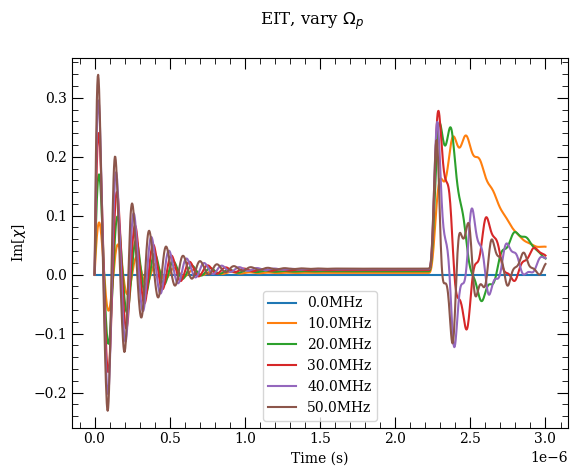

In [23]:
tlist = np.linspace(0.0, 0.000003, 1000)
#print(tlist)
L=7.5e-2 # Cell length

psi0=basis(4,0)

pressure = pressure_Rb85(temperature)
N_0 = atomdensity(pressure, temperature)
dp = np.linspace(-100.e6, 100.e6, 201)
dc = np.linspace(-200.e6, 200.e6, 201)
dp = np.array([0])
# print(dp)
rabi12 = 1e6
rabi23 = 100e6

rabi34 = 0

delta12=0
delta23=0
delta34=0

Rabi12 = np.linspace(0, 50.e6, 6)
Rabi23 = np.linspace(0, 100.e6, 5)
Rabi34 = np.linspace(0, 20.e6, 5)

fig, ax = plt.subplots()
for rabi12 in Rabi12:
# for rabi23 in Rabi23:
# for rabi34 in Rabi34:
    Rabifreq = [rabi12,rabi23,rabi34]
    #print(Rabifreq)
    res = []
    for delta12 in dp:
    # for delta23 in dc:    
        delta = [delta12,delta23,delta34]
        H0 = 1/2*Qobj(Hdiag(delta) + Hoff(Rabifreq))  
        H1 = (rho[2][3].dag() + rho[2][3])
        H = [H0,[H1,H1_coeff]] 
        print(H)
        
        # result = steadystate(H, c_op_list)
        result = mesolve(H, psi0, tlist, c_op_list,rho[0][1].dag())
        
        res.append(result.expect)
    # print(H)   
    # print(c_op_list)
    # print(rabi34)
    # print(res)
    # print(np.imag(res))
    Efield = E_from_Rabi(rabi12,abs(dipmat12))
    # print()
    # chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res]

    # # print(np.imag(chi))
    # transmittance = [transmission(L,np.imag(i),lambda12) for i in chi]
    # refraction = np.real(chi)
    # absorption = 2*pi*np.imag(chi)/lambda12
    # print(np.imag(chi)[0])
    # # print(absorption)
    # # ax.plot(dp, res) 
    # # ax.plot(dp,res, label=omegaRF*1e-6)
    # # ax.plot(dp,transmission, label=rabi34*1e-6)
    # # ax.plot(dp,transmission, label=rabi12*1e-6)
    # # ax.plot(dp,transmittance, label=str(round(rabi12*1e-6,0))+'MHz')

    # # ax.plot(dp,refraction, label=rabi23*1e-6)
    ax.plot(tlist,np.imag(res[0][0]), label=str(round(rabi12*1e-6,0))+'MHz') # for rho[0][1]
    # ax.plot(tlist,np.real(res[0][0]), label=str(round(rabi12*1e-6,0))+'MHz') # for rho[0][0]
    #print(res)

    # ax.plot(times, result.expect[1]) 
ax.set_xlabel('Time (s)') 
ax.set_ylabel('Im[$\chi$]') 
# ax.legend(("Sigma-Z", "Sigma-Y"))  
ax.legend()
# plt.suptitle('EIT, vary $\Omega_{RF}$')
plt.suptitle('EIT, vary $\Omega_{p}$')
# plt.ylim(-0.0007,-0.0006)
plt.show()
#print(H) 
#print(Rabifreq)
#print(delta)
#print(res[0])

In [24]:
t_start = 2e-6 
t_stop = 4e-6 
tlist = np.linspace(0.0, 6E-6 , 2400) 

e:\anaconda\envs\qutopV2_environment\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
e:\anaconda\envs\qutopV2_environment\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


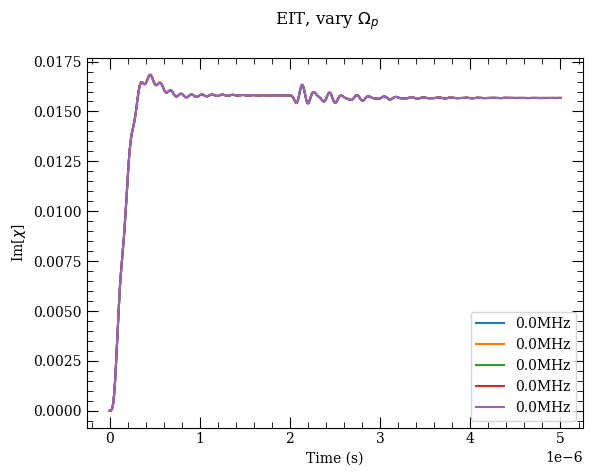

In [25]:

# Define time-dependent coefficient function
def hamiltonian_time_interval(t, args): 
    A = args['A']   
    t_start = args['start']  
    t_stop = args['stop'] 
    if t < t_start:
        return 0 
    elif t_start <= t < t_stop: 
        return A
    else: 
        return 0

# Initialize parameters
psi0 = basis(4, 0)
rabi12 = 0.5e6 
rabi23 = 40e6 
rabi34 = 0 
dp = np.linspace(-100.e6, 100.e6, 201)
dc = np.linspace(-50.e6, 50.e6, 101) 
tlist = np.linspace(0, 5e-6, 500)  # Time list for simulation
t_array = np.linspace(1, 5, 5) * 1e-6  # Time intervals for splitting
Rabifreq = [rabi12, rabi23, rabi34]


# Initialize results
fig, ax = plt.subplots()
res_split_time = []

# Main simulation loop
for interval in t_array: 
    res_split = [] 
    for delta23 in dc:    
        delta = [0, delta23, 0]
        H0 = 1/2 * Qobj(Hdiag(delta) + Hoff(Rabifreq))  
        H1 = 1/2 * (rho[2][3].dag() + rho[2][3])
        H = [H0, [H1, hamiltonian_time_interval]] 
        
        # Solve the master equation
        args = {'A': 20e6, 'start': 2e-6, 'stop': 4e-6 + interval}
        result = mesolve(H, psi0, tlist, c_op_list, [rho[0][1].dag()], args=args)
        
        res_split.append(result.expect)
        Efield = E_from_Rabi(rabi12,abs(dipmat12)) 
    res_split_time.append(res_split)

    # Plot results
    ax.plot(tlist,res_split[2][0], label=str(round(rabi12*1e-6,0))+'MHz')

# Finalize plot
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'Im[$\chi$]')
ax.legend()
plt.suptitle(r'EIT, vary $\Omega_{p}$')
plt.show()


<>:55: SyntaxWarning: invalid escape sequence '\c'
<>:59: SyntaxWarning: invalid escape sequence '\O'
<>:55: SyntaxWarning: invalid escape sequence '\c'
<>:59: SyntaxWarning: invalid escape sequence '\O'
C:\Users\beam_\AppData\Local\Temp\ipykernel_35144\3195416409.py:55: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel('Im[$\chi$]')
C:\Users\beam_\AppData\Local\Temp\ipykernel_35144\3195416409.py:59: SyntaxWarning: invalid escape sequence '\O'
  plt.suptitle('EIT, vary $\Omega_{p}$')


3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-0

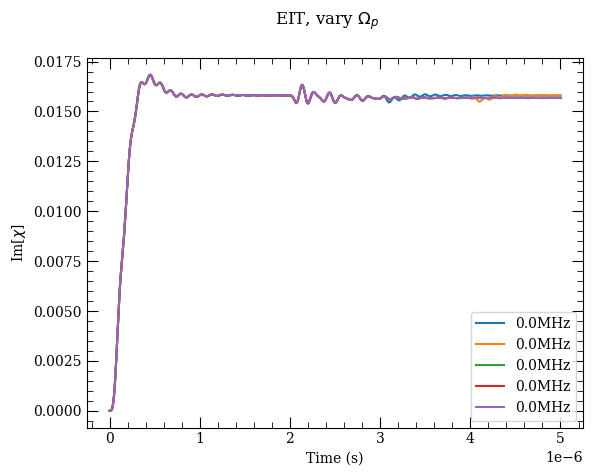

In [26]:

psi0=basis(4,0)
rabi12 = 0.5e6 
rabi23 = 40e6 
rabi34 = 0 
t_start = 2e-6 
t_stop = 4e-6 
rabi34_value = 20e6  
dp = np.linspace(-100.e6, 100.e6, 201)
dc = np.linspace(-50.e6, 50.e6, 101) 
t_array = np.linspace(1,5,5)*1e-6 
# for rabi23 in Rabi23:
# for rabi34 in Rabi34:
Rabifreq = [rabi12,rabi23,rabi34]
    #print(Rabifreq)

fig, ax = plt.subplots()
res_split_time = []
    #for delta12 in dp:  
for interval in t_array: 
    res_split = [] 
    for delta23 in dc:    
        delta = [delta12,delta23,delta34]
        H0 = 1/2*Qobj(Hdiag(delta) + Hoff(Rabifreq))  
        H1 = 1/2*(rho[2][3].dag() + rho[2][3])
        H = [H0,[H1,hamiltonian_time_interval]] 
    #    print(H)
        
    # result = steadystate(H, c_op_list)
        result = mesolve(H, psi0, tlist, c_op_list,rho[0][1].dag(),args={'A': rabi34_value ,'start' : t_start ,'stop' : t_start  + interval})
        print(t_start + interval)
        res_split.append(result.expect)
    # print(H)   
    # print(c_op_list)
    # print(rabi34)
    #    print(res_split[0][0])
    # print(np.imag(res))
        Efield = E_from_Rabi(rabi12,abs(dipmat12)) 
    res_split_time.append(res_split)
    # print()
    #chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res[0]]
    # # print(np.imag(chi))
    # transmittance = [transmission(L,np.imag(i),lambda12) for i in chi]
    # refraction = np.real(chi)
    # absorption = 2*pi*np.imag(chi)/lambda12
    # print(np.imag(chi)[0])
    # # print(absorption)
    
    # # ax.plot(dp,refraction, label=rabi23*1e-6)
    ax.plot(tlist,res_split[2][0], label=str(round(rabi12*1e-6,0))+'MHz') # for rho[0][1]
    # ax.plot(tlist,np.real(res[0][0]), label=str(round(rabi12*1e-6,0))+'MHz') # for rho[0][0]
    #print(res)

# ax.plot(times, result.expect[1]) 
ax.set_xlabel('Time (s)') 
ax.set_ylabel('Im[$\chi$]') 
# ax.legend(("Sigma-Z", "Sigma-Y"))  
ax.legend()
# plt.suptitle('EIT, vary $\Omega_{RF}$')
plt.suptitle('EIT, vary $\Omega_{p}$')
# plt.ylim(-0.0007,-0.0006) 
plt.show()

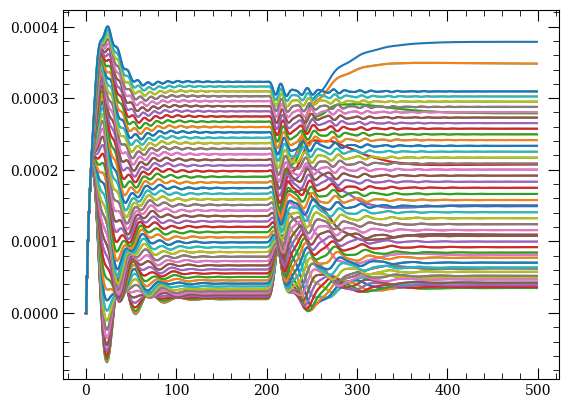

In [27]:
Efield = E_from_Rabi(rabi12,abs(dipmat12)) 
chi_list = []
for i in range(len(dc)):  
    chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res_split[i][0]] 
    chi_list.append(chi)
    plt.plot(np.imag(chi)) 
plt.show()

In [28]:
Efield = E_from_Rabi(rabi12,abs(dipmat12))  
chi_list_time = []
for time in range(len(t_array)):  
    chi_list = [] 
    print(t_array[time])
    for i in range(len(dc)):   
        res_split = res_split_time[time] 
        chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res_split[i][0]] 
        chi_list.append(chi)
    chi_list_time.append(chi_list)

1e-06
2e-06
3e-06
4e-06
4.9999999999999996e-06


<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
C:\Users\beam_\AppData\Local\Temp\ipykernel_35144\3551125643.py:7: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(tlist, -1 * np.imag(chi_list_time[i][50]), label=f"{t:.1f} ($\mu$s)")


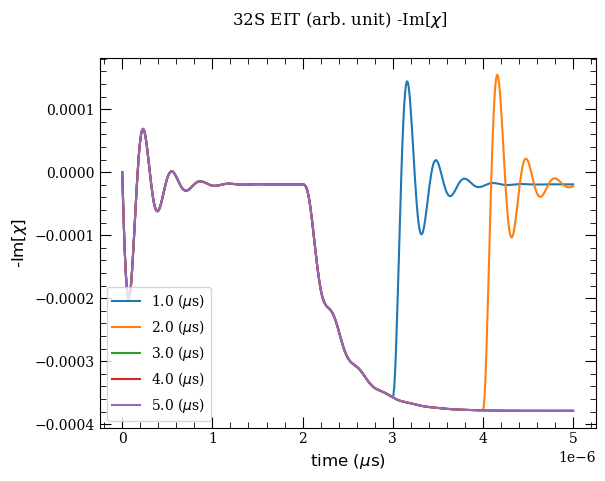

In [29]:
font1 = {'family': 'serif', 'fontsize': 14}  # Use fontsize
font2 = {'family': 'sans-serif', 'fontsize': 12}

frame_time = []
for i in range(len(t_array)):   
    t = t_array[i] * 1e6
    plt.plot(tlist, -1 * np.imag(chi_list_time[i][50]), label=f"{t:.1f} ($\mu$s)")  
    frame_time.append(-1 * np.imag(chi_list_time[i][50])) 

# Set titles and labels
plt.suptitle('32S EIT (arb. unit) ' + r'-Im[$\chi$]', fontdict=font1) 
plt.xlabel("time" + r" ($\mu$s)", fontdict=font2) 
plt.ylabel(r"-Im[$\chi$]", fontdict=font2)
plt.legend()  
plt.show()


In [30]:
t_array = np.array([0.1,1,2,3,4,5])*1e-6  
tlist = np.linspace(0.0, 12E-6 , 2400) 
rabi12 = 0.5e6 
rabi23 = 40e6 
rabi34 = 0 
rabi34_value = 20e6  
#omegaC_list = np.array([5,10,25,50,100])*1e6 
omegaC_list = np.array([10])*1e6
dp = np.linspace(-100.e6, 100.e6, 201)
dc = np.linspace(-50.e6, 50.e6, 201)  
dc_on_off = np.array([0,rabi34_value/2])
#t_array = np.linspace(1,5,5)*1e-6 
# for rabi23 in Rabi23:
# for rabi34 in Rabi34:
Rabifreq = [rabi12,rabi23,rabi34]
    #print(Rabifreq) 
res_split_compare_time = []
for interval in t_array:
    res_split_compare = []
    for rabi23 in omegaC_list: 
        res_split = [] 
        for delta23 in dc_on_off:    
            delta = [delta12,delta23,delta34]  
            Rabifreq = [rabi12,rabi23,rabi34]
            H0 = 1/2*Qobj(Hdiag(delta) + Hoff(Rabifreq))  
            H1 = 1/2*(rho[2][3].dag() + rho[2][3])
            H = [H0,[H1,hamiltonian_time_interval]] 
        #    print(H)
            
        # result = steadystate(H, c_op_list)
            result = mesolve(H, psi0, tlist, c_op_list,rho[0][1].dag(),args={'A': rabi34_value ,'start' : t_start,'stop' : t_start + interval})
            #print(t_start + interval)
            res_split.append(result.expect)
        # print(H)   
        # print(c_op_list)
        # print(rabi34)
        #    print(res_split[0][0])
        # print(np.imag(res))
            Efield = E_from_Rabi(rabi12,abs(dipmat12)) 
        res_split_compare.append(res_split) 
    res_split_compare_time.append(res_split_compare)

# Plotting
ax.set_xlabel(r'Time (s)')  # Use raw string for label
ax.set_ylabel(r'Im[$\chi$]')  # Use raw string for label
ax.legend()
plt.suptitle(r'EIT, vary $\Omega_{p}$')  # Use raw string for title
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
#len(res_split_compare_time[4][4]) 

IndexError: list index out of range

In [32]:
Efield = E_from_Rabi(rabi12,abs(dipmat12))   
chi_list_compare_time = []
for interval in range(len(t_array)):  
    chi_list = [] 
    for i in range(len(dc_on_off)):   
        res_split = res_split_compare_time[interval][0] 
        chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res_split[i][0]] 
        chi_list.append(chi)
    chi_list_compare_time.append(chi_list)

In [33]:
len(chi_list_compare_time[1][1])

2400

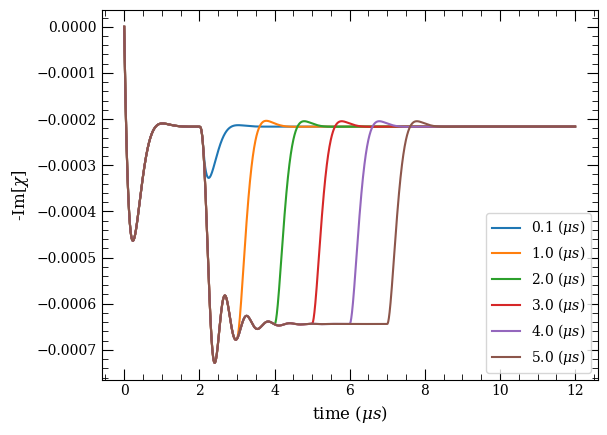

In [34]:
#For on resonant results
from matplotlib import font_manager

# Configure Matplotlib to use serif fonts
plt.rc('font', family='serif')  # Set default font to serif
plt.rc('mathtext', fontset='custom')  # Customize math font
plt.rc('mathtext', rm='serif')  # Roman font for math text
plt.rc('mathtext', it='serif:italic')  # Italic font for math text

# Plot data
im_chi_on_resonance_time = [] 
on = 0
off = 1
for i in range(len(t_array)):    
    t = t_array[i] * 1e6  # Convert time to microseconds
    im_chi_on_resonance_time.append(-1 * np.imag(chi_list_compare_time[i][on]))
    plt.plot(
        tlist * 1e6, 
        -1 * np.imag(chi_list_compare_time[i][on]), 
        label=fr"${t:.1f} \ \mathit{{(\mu s)}}$"
    )

# Configure axis labels with font size 12
plt.xlabel(r"time $\mathit{(\mu s)}$", fontsize=12) 
plt.ylabel(r"-Im[$\chi$]", fontsize=12)

# Add title
#plt.title(r"32S EIT (arb. unit) " + r"-Im[$\chi$]", fontsize=14)

# Add legend
plt.legend(loc='lower right')

# Save and show the plot
fig = plt.gcf()
fig.savefig("simulation_on_resonance_serif.png", dpi=300, bbox_inches='tight') 
fig.savefig("simulation_on_resonance_serif.tiff", dpi=300, format='tiff', bbox_inches='tight')
plt.show()

tlist: [0.00000000e+00 5.00208420e-09 1.00041684e-08 ... 1.19899958e-05
 1.19949979e-05 1.20000000e-05]
chi_list_compare_time shape: (6, 2, 2400)


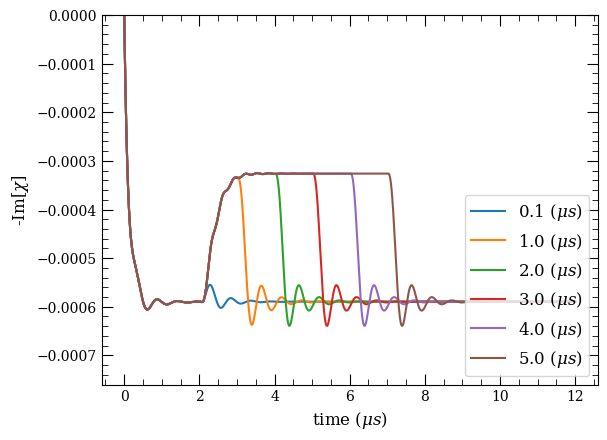

In [35]:
#For off resonant results

from matplotlib import font_manager

# Debugging: Check data
print("tlist:", tlist)
print("chi_list_compare_time shape:", np.shape(chi_list_compare_time))

# Configure Matplotlib to use serif fonts
plt.rc('font', family='serif')  # Set default font to serif
plt.rc('mathtext', fontset='custom')  # Customize math font
plt.rc('mathtext', rm='serif')  # Roman font for math text
plt.rc('mathtext', it='serif:italic')  # Italic font for math text

# Plot data
im_chi_off_resonance_time = [] 
on = 0
off = 1
for i in range(len(t_array)):    
    t = t_array[i] * 1e6  # Convert time to microseconds
    im_chi_off_resonance_time.append(-1 * np.imag(chi_list_compare_time[i][off]))
    # Update the legend label with italicized (μs)
    plt.plot(
        tlist * 1e6, 
        -1 * np.imag(chi_list_compare_time[i][off]), 
        label=fr"${t:.1f} \ \mathit{{(\mu s)}}$"
    )

# Set title and axis labels with font size 12 for axis labels
plt.xlabel(r"time $\mathit{(\mu s)}$", fontsize=12) 
plt.ylabel(r"-Im[$\chi$]", fontsize=12)

# Set y-axis scale
plt.ylim(-0.00076, 0.000)  # Set y-axis limits

# Add legend with matching serif font
plt.legend(loc='lower right', fontsize=12)

# Save and show the plot
fig = plt.gcf()
fig.savefig("simulation_off_resonance.png", dpi=300, bbox_inches='tight') 
fig.savefig("simulation_off_resonance.tiff", dpi=300, format='tiff', bbox_inches='tight') 

plt.show()

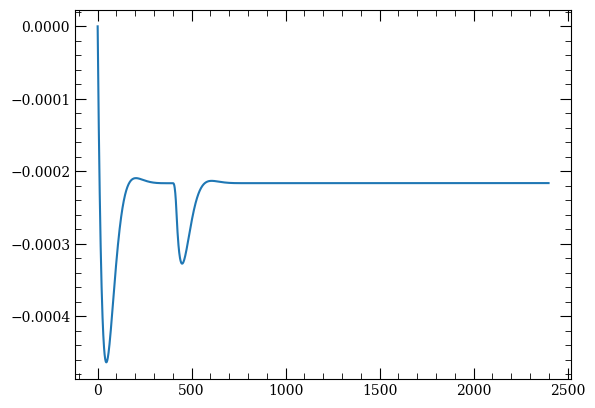

In [36]:
plt.plot(im_chi_on_resonance_time[0])  
len(im_chi_on_resonance_time[0])
plt.show()

In [37]:
#For on resonant
data_chi_on_resonance = [] 
Efield = E_from_Rabi(rabi12,abs(dipmat12))   
for rabi in range(len(omegaC_list)):    
    chi_list_compare_time = []
    for interval in range(len(t_array)):  
        chi_list = [] 
        for i in range(len(dc_on_off)):   
            res_split = res_split_compare_time[interval][rabi] 
            chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res_split[i][0]] 
            chi_list.append(chi) 
        chi_list_compare_time.append(chi_list[0])  
    data_chi_on_resonance.append(chi_list_compare_time)

In [38]:
len(data_chi_on_resonance[0])

6

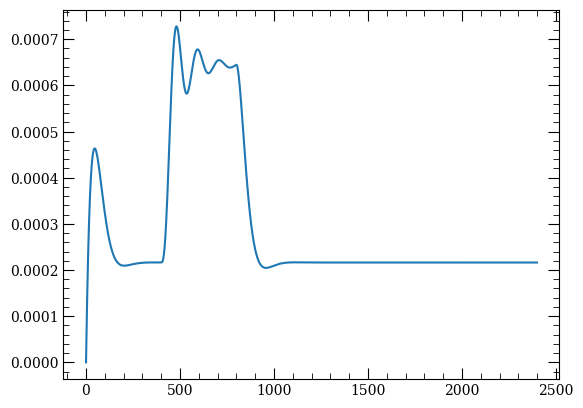

In [39]:
plt.plot(np.imag(data_chi_on_resonance[0][2]))
plt.show()

In [40]:
#For on resonant
data_chi_off_resonance = [] 
Efield = E_from_Rabi(rabi12,abs(dipmat12))   
for rabi in range(len(omegaC_list)):    
    chi_list_compare_time = []
    for interval in range(len(t_array)):  
        chi_list = [] 
        for i in range(len(dc_on_off)):   
            res_split = res_split_compare_time[interval][rabi] 
            chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res_split[i][0]] 
            chi_list.append(chi) 
        chi_list_compare_time.append(chi_list[1])  
    data_chi_off_resonance.append(chi_list_compare_time)

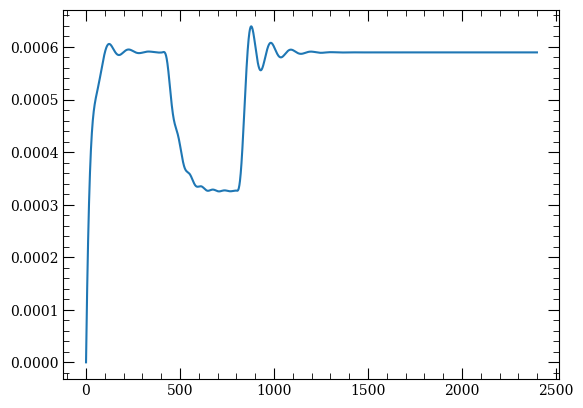

In [41]:
plt.plot(np.imag(data_chi_off_resonance[0][2]))
plt.show()

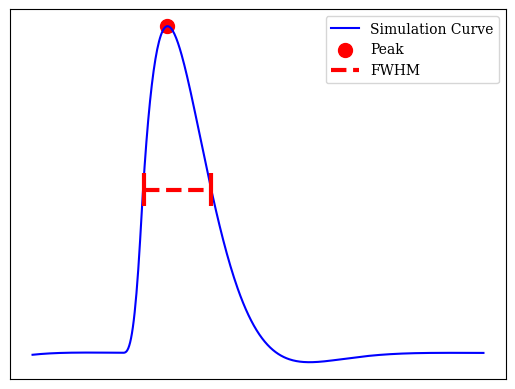

In [ ]:
# Generate Gaussian-like data
x = np.arange(0, 500)
y = 10000 * np.imag(data_chi_on_resonance[0][0])[300:800] 
base_line = np.nanmean(y[0:50])  

# Find the peak index and value
peak_idx = np.argmax(y)  # Index of max value
peak_x = x[peak_idx]
peak_y = y[peak_idx]

# Compute Full Width at Half Maximum (FWHM)
half_max = (peak_y + base_line) / 2  # Half of the peak value 
indices = np.where(y >= half_max)[0]  # Find indices where y is greater than half max

left_idx, right_idx = indices[0], indices[-1]  # Left and right intersection points
left_x, right_x = x[left_idx], x[right_idx]  # X values at FWHM

# Plot the Gaussian curve
plt.plot(x, y, label="Simulation Curve", color='blue')

# Add red dot at the peak
plt.scatter(peak_x, peak_y, color='red', s=100, label="Peak")

# **Draw a THICK, DASHED horizontal FWHM line**
plt.hlines(half_max, left_x, right_x, color='red', linewidth=3, linestyle="--", label="FWHM")

# **Make vertical FWHM tick bars thicker and longer**
tick_extension = 0.05 * (peak_y - base_line)  # Extend tick bars
tick_positions = np.array([left_x, right_x])
plt.vlines(tick_positions, half_max - tick_extension, half_max + tick_extension, color='red', linewidth=3)  # Thicker & longer tick bars

# Enable grid for both axes
plt.grid(True, which='both', linestyle='-', linewidth=0.5, color='black')

# Remove tick labels (numbers) but keep the grid lines
plt.xticks([])
plt.yticks([])

# Keep the plot spines visible
plt.gca().spines['top'].set_visible(True)
plt.gca().spines['right'].set_visible(True)
plt.gca().spines['bottom'].set_visible(True)
plt.gca().spines['left'].set_visible(True)

plt.legend()

# Save the image
plt.savefig("measure_narrow_line.png", dpi=300, bbox_inches='tight')  # Saves as PNG with high quality 
plt.show()

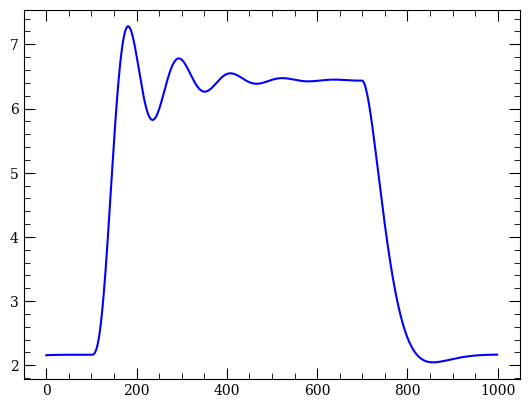

In [87]:
x = np.arange(0, 1000)
y = 10000 * np.imag(data_chi_on_resonance[0][3])[300:1300] 
# Plot the Gaussian curve
plt.plot(x, y, label="Simulation Curve", color='blue') 
plt.show()

In [ ]:

# Example Data (Replace with your real data)
t_array = np.linspace(0, 5, 10)  # Pulse duration (in µs)
on_resonance = t_array + np.random.uniform(-0.2, 0.2, len(t_array))  # Simulated On-Resonance
off_resonance = t_array + np.random.uniform(-0.3, 0.3, len(t_array))  # Simulated Off-Resonance

# Create Figure
fig, ax = plt.subplots(figsize=(8,6))

# Shade Region 1 (Light Blue) & Region 2 (Light Green)
ax.axvspan(0, 1, color="#ADD8E6", alpha=0.5, label="Region 1 (0-1 µs)")
ax.axvspan(1, 5, color="#90EE90", alpha=0.5, label="Region 2 (1-5 µs)")

# Plot Data Points
ax.scatter(t_array, on_resonance, color="blue", marker="o", label=r"Simulation ($\Delta_C = 0.0$ MHz)")
ax.scatter(t_array, off_resonance, color="green", marker="D", label=r"Simulation ($\Delta_C = 10.0$ MHz)")

# Dashed Line for Ideal Pulse Duration
ax.plot(t_array, t_array, linestyle="--", color="gold", marker="*", label="Ideal Pulse Duration")

# Formatting
ax.set_xlabel("Pulse duration (µs)", fontsize=12)
ax.set_ylabel("Measuring time (µs)", fontsize=12)
ax.legend()
ax.grid(True, linestyle="--", linewidth=0.5)

# Add Subplots (Gaussian in Region 1, Sine in Region 2)
# Gaussian Curve (Region 1)
left_inset = fig.add_axes([0.15, 0.78, 0.2, 0.15])  # [x, y, width, height]
x_gaussian = np.linspace(-2, 2, 100)
y_gaussian = np.exp(-x_gaussian**2)
left_inset.plot(x_gaussian, y_gaussian, color="blue", linewidth=2)
left_inset.set_xticks([])
left_inset.set_yticks([])
left_inset.set_title("Region 1 (Narrow)", fontsize=10)

# Sine Wave (Region 2)
right_inset = fig.add_axes([0.65, 0.78, 0.2, 0.15])  # [x, y, width, height]
x_sine = np.linspace(0, 2*np.pi, 100)
y_sine = np.sin(x_sine)
right_inset.plot(x_sine, y_sine, color="darkgreen", linewidth=2)
right_inset.set_xticks([])
right_inset.set_yticks([])
right_inset.set_title("Region 2 (Large)", fontsize=10)

# Save and Show
plt.savefig("final_2_region_plot.png", dpi=300, bbox_inches='tight')
plt.show()

1900
[127 575]


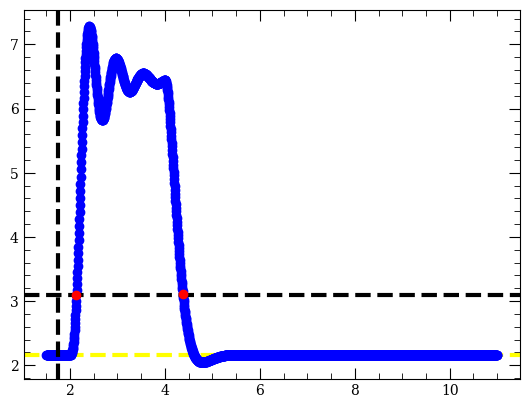

In [42]:
# For on resonant 

start_crop = 300
end_crop = 2200
time_duration = tlist[start_crop:end_crop] 
data_pulse = np.imag(data_chi_on_resonance[0][2])[start_crop:end_crop]  
print(len(data_pulse))
x_data = time_duration*1e6
y_data = data_pulse*1e4 

horizontal_line = np.nanmean(y_data)   
base_line = np.nanmean(y_data[-300:-1]) 
plt.axhline(base_line,color='yellow', linestyle='--', linewidth=3,label = "Max line")  
plt.plot(x_data,y_data, 'bo') 
plt.axhline(horizontal_line,color='black', linestyle='--', linewidth=3,label = "Max line")  
idx = np.argwhere(np.diff(np.sign(y_data - horizontal_line))).flatten()  
cut_point = 50 
plt.axvline(x_data[cut_point],color='black', linestyle='--', linewidth=3,label = "Max line") 
idx = np.delete(idx,np.where(idx < cut_point))  
print(idx)
plt.plot(x_data[idx], y_data[idx], 'ro') 
plt.show()

1900
[141 551]


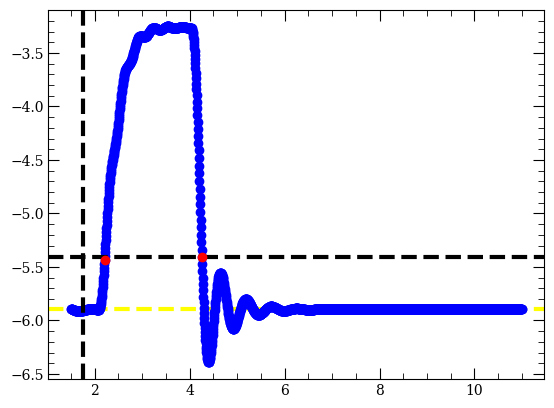

In [43]:
# For off resonant 

start_crop = 300
end_crop = 2200
time_duration = tlist[start_crop:end_crop] 
data_pulse = -1*np.imag(data_chi_off_resonance[0][2])[start_crop:end_crop]  
print(len(data_pulse))
x_data = time_duration*1e6
y_data = data_pulse*1e4 

horizontal_line = np.nanmean(y_data)   
base_line = np.nanmean(y_data[-300:-1]) 
plt.axhline(base_line,color='yellow', linestyle='--', linewidth=3,label = "Max line")  
plt.plot(x_data,y_data, 'bo') 
plt.axhline(horizontal_line,color='black', linestyle='--', linewidth=3,label = "Max line")  
idx = np.argwhere(np.diff(np.sign(y_data - horizontal_line))).flatten()  
cut_point = 50 
plt.axvline(x_data[cut_point],color='black', linestyle='--', linewidth=3,label = "Max line") 
idx = np.delete(idx,np.where(idx < cut_point))  
print(idx)
plt.plot(x_data[idx], y_data[idx], 'ro') 
plt.show()

In [94]:
def classify_rectangle(data_sim_time_array,num_file,start_crop,end_crop):  
    if end_crop > len(tlist): 
        end_crop = len(tlist)
    time_duration = tlist[start_crop:end_crop]
    data_pulse = data_sim_time_array[int(num_file)][start_crop:end_crop] 
    x_data = time_duration*1e6
    y_data = data_pulse*1e4 

    horizontal_line = np.nanmean(y_data)   
    base_line = np.nanmean(y_data[-300:-1]) 
    plt.axhline(base_line,color='orange', linestyle='--', linewidth=3,label = "Baseline")  
    plt.plot(x_data,y_data) 
    #plt.axhline(horizontal_line,color='black', linestyle='--', linewidth=3,label = "Max line") 
    idx = np.argwhere(np.diff(np.sign(y_data - horizontal_line))).flatten()  
    idx = np.delete(idx,np.where(idx < 50))  
    print(idx)
    #plt.plot(x_data[idx], y_data[idx], 'yo') 
    if (idx[1]-idx[0]) < 400 :  
        peaks = np.argmax(y_data)
        print(peaks,base_line)
        half_max = (y_data[peaks] + base_line)*0.5 
        idx_half = np.argwhere(np.diff(np.sign(y_data - half_max))).flatten()  
        print(idx_half)   
        if len(idx_half) > 2 :  
            closet_idx = np.delete(idx_half,np.where(idx_half < int(peaks/3)))
        else : 
            closet_idx = idx_half 
        print("closet_index  to peak = ",closet_idx)
        #sorted_idx = sorted(idx_half, key=lambda x: abs(x - peaks))  
        #closet_idx = sorted_idx[:2]
        plt.plot(x_data[closet_idx][:2], y_data[closet_idx][:2], 'ro',label = "Intersection points")   
        print('half_max = ',half_max)   
        fwm_rectan = x_data[closet_idx][1] - x_data[closet_idx][0]
        print('FWM = ',fwm_rectan)
    else: 
        # Initialize the RectangleModel and ConstantModel
        rect_model = RectangleModel()
        const_model = ConstantModel()

        # Combine the models
        model = rect_model + const_model 
    

        # Guess the initial parameters
        params = model.make_params()
        params.update(rect_model.guess(y_data, x=x_data))
        params.update(const_model.guess(y_data, x=x_data))

        # Print the guessed parameters
        print("Guessed Parameters:")
        for name, param in params.items():
            print(f"{name}: {param.value}")
        # Set constraints on the parameters 
        # previous value 
        #params['amplitude'].max = 2.25  and 4.25 
        # params['amplitude'].max = 4.10
        params['amplitude'].max = 4.26
        # Fit the model to the noisy data
        result = model.fit(y_data, params, x=x_data) 
        # Print the fit report
        print(result.fit_report()) 
        fwm_rectan =  result.params['center2'].value - result.params['center1'].value 
        plt.plot(x_data, result.best_fit, color='red', label='Best Fit')
        #plt.xlabel('X')
        #plt.ylabel('Y')
        plt.title('classify rectangle')
        plt.legend()  
        
        if result.rsquared < 0.922 :
            peaks = np.argmax(y_data)
            half_max = (y_data[peaks] + base_line)*0.5 
            idx_half = np.argwhere(np.diff(np.sign(y_data - half_max))).flatten()  
            print(idx_half)   
            if len(idx_half) > 2 :  
                closet_idx = np.delete(idx_half,np.where(idx_half < int(peaks/3)))
            else : 
                closet_idx = idx_half 
            print("closet_index  to peak = ",closet_idx)
            #sorted_idx = sorted(idx_half, key=lambda x: abs(x - peaks))  
            #closet_idx = sorted_idx[:2]
            plt.plot(x_data[closet_idx][:2], y_data[closet_idx][:2], 'yo',label = "Intersection points")  
            print('half_max = ',half_max)   
            fwm_rectan = x_data[closet_idx][1] - x_data[closet_idx][0]
            print('FWM = ',fwm_rectan) 
        else: 
            fwm_rectan = fwm_rectan
    #plt.axvline(x_data[300],color='black', linestyle='--', linewidth=3,label = "Max line")  
    #plt.axvline(x_data[end_crop-500],color='black', linestyle='--', linewidth=3,label = "Max line")  
    # Remove tick labels (numbers) but keep the grid lines
    plt.xticks([])
    plt.yticks([])

    # Keep the plot spines visible
    plt.gca().spines['top'].set_visible(True)
    plt.gca().spines['right'].set_visible(True)
    plt.gca().spines['bottom'].set_visible(True)
    plt.gca().spines['left'].set_visible(True)

    plt.show()   
    return fwm_rectan

[109 252]
149 2.1627889781999357
[122 197]
closet_index  to peak =  [122 197]
half_max =  2.7186442382997167
FWM =  0.37515631513130465


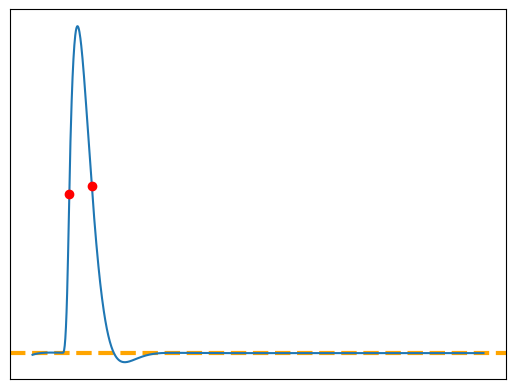

[122 385]
181 2.162790396839472
[143 342]
closet_index  to peak =  [143 342]
half_max =  4.721475450632624
FWM =  0.9954147561483957


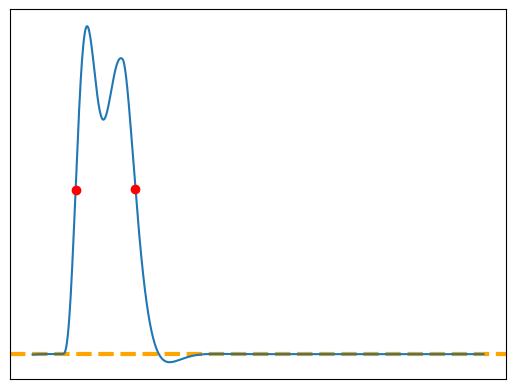

[129 568]
Guessed Parameters:
amplitude: 5.234416823556204
center1: 2.6248436848686953
sigma1: 1.0711606026320493
center2: 7.874531054606086
sigma2: 1.0711606026320493
c: 3.3448796220899
midpoint: 5.249687369737391
[[Model]]
    (Model(rectangle, form='linear') + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 452
    # data points      = 1500
    # variables        = 6
    chi-square         = 1779.90537
    reduced chi-square = 1.19136905
    Akaike info crit   = 268.642635
    Bayesian info crit = 300.521957
    R-squared          = 0.65631352
[[Variables]]
    amplitude: -3.17796167 +/- 0.13885322 (4.37%) (init = 4.26)
    center1:    4.31818599 +/- 0.01676484 (0.39%) (init = 2.624844)
    sigma1:     0.18320393 +/- 0.02682437 (14.64%) (init = 1.071161)
    center2:    211.131439 +/- 838.088475 (396.95%) (init = 7.874531)
    sigma2:     206.282014 +/- 846.601438 (410.41%) (init = 1.071161)
    c:          5.31955318 +/- 0.04754642 (0.8

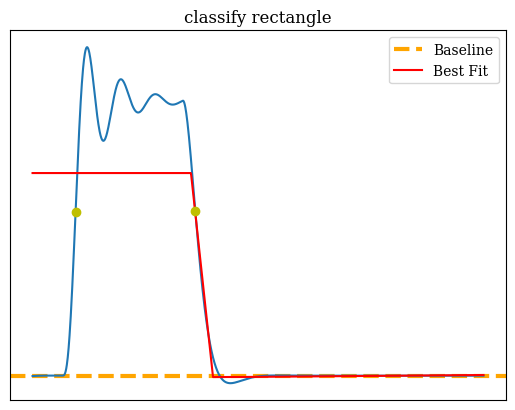

[135 755]
Guessed Parameters:
amplitude: 5.234059390991897
center1: 2.6248436848686953
sigma1: 1.0711606026320493
center2: 7.874531054606086
sigma2: 1.0711606026320493
c: 3.9136185377651254
midpoint: 5.249687369737391
[[Model]]
    (Model(rectangle, form='linear') + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 220
    # data points      = 1500
    # variables        = 6
    chi-square         = 36.8588478
    reduced chi-square = 0.02467125
    Akaike info crit   = -5547.18704
    Bayesian info crit = -5515.30772
    R-squared          = 0.99417562
##  Warning: uncertainties could not be estimated:
    amplitude:  at initial value
    amplitude:  at boundary
[[Variables]]
    amplitude:  4.26000000 (init = 4.26)
    center1:    2.19382303 (init = 2.624844)
    sigma1:     0.10821600 (init = 1.071161)
    center2:    5.25439156 (init = 7.874531)
    sigma2:     0.22871319 (init = 1.071161)
    c:          2.17594489 (init = 3.913619)
    

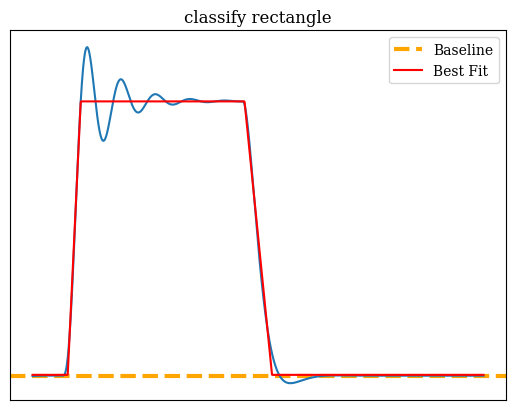

[140 944]
Guessed Parameters:
amplitude: 5.2341889759269105
center1: 2.6248436848686953
sigma1: 1.0711606026320493
center2: 7.874531054606086
sigma2: 1.0711606026320493
c: 4.483701253789034
midpoint: 5.249687369737391
[[Model]]
    (Model(rectangle, form='linear') + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 186
    # data points      = 1500
    # variables        = 6
    chi-square         = 36.8266569
    reduced chi-square = 0.02464970
    Akaike info crit   = -5548.49765
    Bayesian info crit = -5516.61832
    R-squared          = 0.99433799
##  Warning: uncertainties could not be estimated:
    amplitude:  at initial value
    amplitude:  at boundary
[[Variables]]
    amplitude:  4.26000000 (init = 4.26)
    center1:    2.19394685 (init = 2.624844)
    sigma1:     0.10821600 (init = 1.071161)
    center2:    6.25431346 (init = 7.874531)
    sigma2:     0.22856307 (init = 1.071161)
    c:          2.17838211 (init = 4.483701)
    

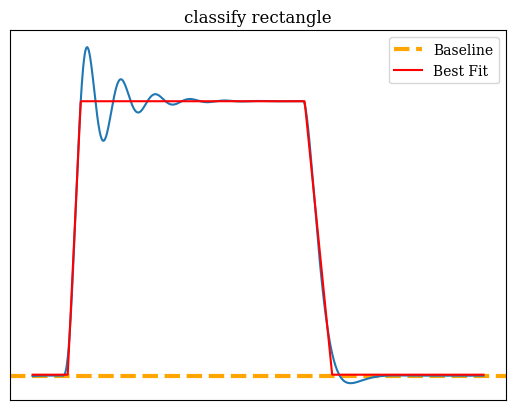

[ 146 1134]
Guessed Parameters:
amplitude: 5.234186874685614
center1: 2.6248436848686953
sigma1: 1.0711606026320493
center2: 7.874531054606086
sigma2: 1.0711606026320493
c: 5.053666472677744
midpoint: 5.249687369737391
[[Model]]
    (Model(rectangle, form='linear') + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 202
    # data points      = 1500
    # variables        = 6
    chi-square         = 36.7585871
    reduced chi-square = 0.02460414
    Akaike info crit   = -5551.27279
    Bayesian info crit = -5519.39347
    R-squared          = 0.99355636
[[Variables]]
    amplitude:  4.26000000 +/- 3.0100e-05 (0.00%) (init = 4.26)
    center1:    2.19441779 +/- 0.00122679 (0.06%) (init = 2.624844)
    sigma1:     0.10725154 +/- 0.00209396 (1.95%) (init = 1.071161)
    center2:    7.25370016 +/- 0.00182320 (0.03%) (init = 7.874531)
    sigma2:     0.22745905 +/- 0.00307907 (1.35%) (init = 1.071161)
    c:          2.18118889 +/- 0.00763567 (0.

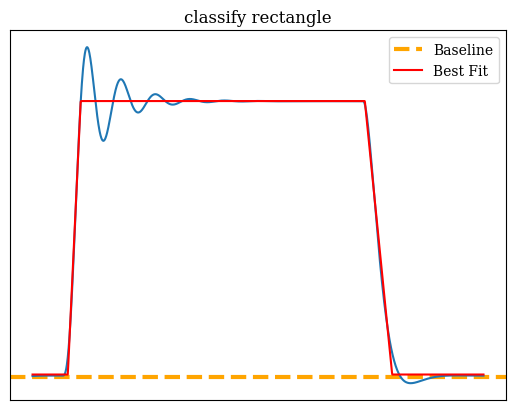

In [95]:
#For on resonant

data_cross_segment_width_on = [] 
for rabi in range(len(omegaC_list)):   
    im_chi_on_resonance_time = np.imag(data_chi_on_resonance[rabi]) 
    #print(omegaC_list[rabi]) 
    on_resonance_result = []
    for i in range(0,len(im_chi_on_resonance_time)):   
        #print(t_array[i]-t_array[0]) 
        dat = classify_rectangle(im_chi_on_resonance_time,i,300,1800)
        on_resonance_result.append(dat)   
        plt.show()
    data_cross_segment_width_on.append(on_resonance_result) 
data_cross_segment_width_on = np.array(data_cross_segment_width_on)

[120 191 244 294 355 395]
156 -5.896089643593604
[134 178]
closet_index  to peak =  [134 178]
half_max =  -5.7218271583765885
FWM =  0.2200917048770319


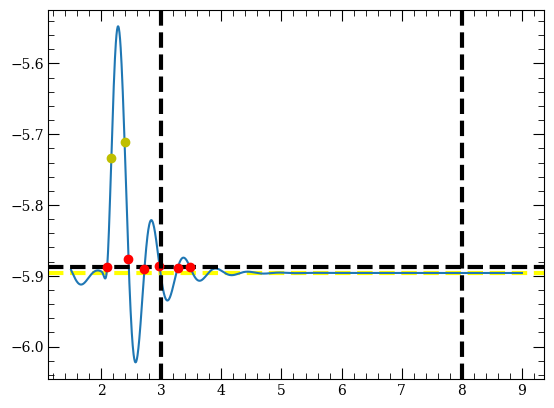

[135 354 419 440]
293 -5.896091231755771
[167 339]
closet_index  to peak =  [167 339]
half_max =  -4.618207144769816
FWM =  0.8603584827011259


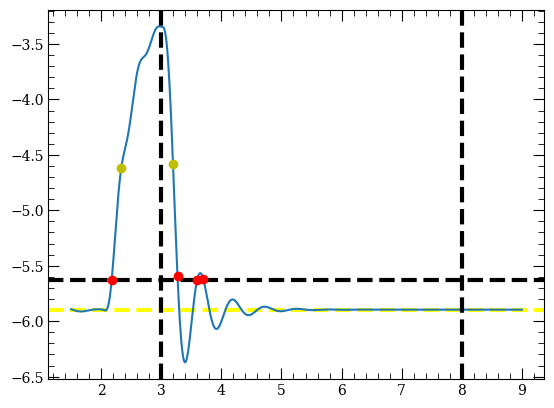

[145 549]
Guessed Parameters:
amplitude: 3.1400776103624546
center1: 2.6248436848686953
sigma1: 1.0711606026320493
center2: 7.874531054606086
sigma2: 1.0711606026320493
c: -5.279664286256616
midpoint: 5.249687369737391
[[Model]]
    (Model(rectangle, form='linear') + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 116
    # data points      = 1500
    # variables        = 6
    chi-square         = 14.2968188
    reduced chi-square = 0.00956949
    Akaike info crit   = -6967.77500
    Bayesian info crit = -6935.89568
    R-squared          = 0.99140352
[[Variables]]
    amplitude:  2.58725168 +/- 0.00660500 (0.26%) (init = 3.140078)
    center1:    2.38946380 +/- 0.00230076 (0.10%) (init = 2.624844)
    sigma1:     0.32264974 +/- 0.00381108 (1.18%) (init = 1.071161)
    center2:    4.19818459 +/- 0.00121277 (0.03%) (init = 7.874531)
    sigma2:     0.09917952 +/- 0.00205259 (2.07%) (init = 1.071161)
    c:         -5.90334987 +/- 0.00301317

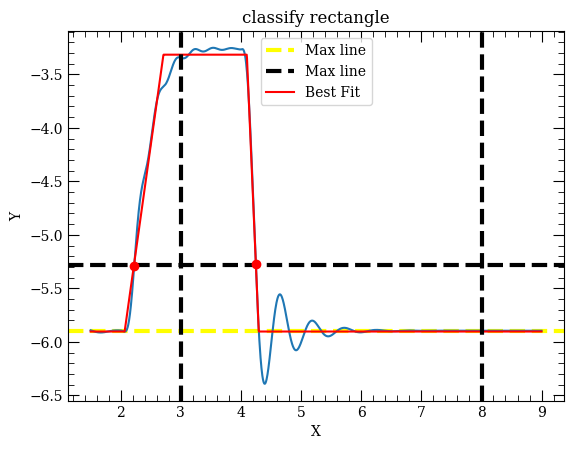

[155 744]
Guessed Parameters:
amplitude: 3.141222874482237
center1: 2.6248436848686953
sigma1: 1.0711606026320493
center2: 7.874531054606086
sigma2: 1.0711606026320493
c: -4.928735613434853
midpoint: 5.249687369737391
[[Model]]
    (Model(rectangle, form='linear') + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 85
    # data points      = 1500
    # variables        = 6
    chi-square         = 14.6491933
    reduced chi-square = 0.00980535
    Akaike info crit   = -6931.25268
    Bayesian info crit = -6899.37336
    R-squared          = 0.99339109
[[Variables]]
    amplitude:  2.61353865 +/- 0.00567287 (0.22%) (init = 3.141223)
    center1:    2.39349923 +/- 0.00228808 (0.10%) (init = 2.624844)
    sigma1:     0.32953098 +/- 0.00382518 (1.16%) (init = 1.071161)
    center2:    5.19669409 +/- 0.00121203 (0.02%) (init = 7.874531)
    sigma2:     0.10073817 +/- 0.00204078 (2.03%) (init = 1.071161)
    c:         -5.90516007 +/- 0.00339045 (

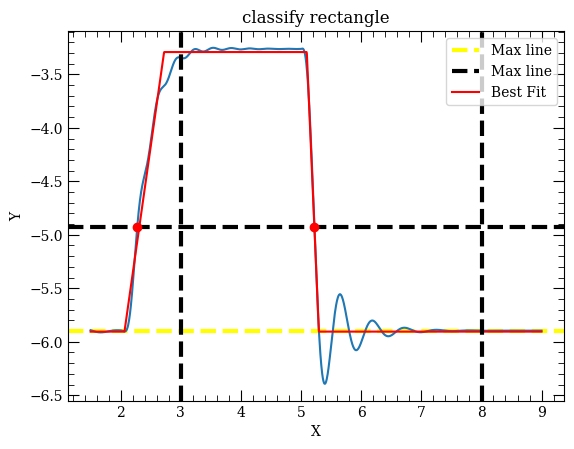

[169 939]
Guessed Parameters:
amplitude: 3.1406752630445016
center1: 2.6248436848686953
sigma1: 1.0711606026320493
center2: 7.874531054606086
sigma2: 1.0711606026320493
c: -4.577703448939511
midpoint: 5.249687369737391
[[Model]]
    (Model(rectangle, form='linear') + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 85
    # data points      = 1500
    # variables        = 6
    chi-square         = 14.7287441
    reduced chi-square = 0.00985860
    Akaike info crit   = -6923.12913
    Bayesian info crit = -6891.24981
    R-squared          = 0.99386261
[[Variables]]
    amplitude:  2.62548288 +/- 0.00545188 (0.21%) (init = 3.140675)
    center1:    2.39492945 +/- 0.00229010 (0.10%) (init = 2.624844)
    sigma1:     0.33288996 +/- 0.00384713 (1.16%) (init = 1.071161)
    center2:    6.19639927 +/- 0.00122791 (0.02%) (init = 7.874531)
    sigma2:     0.10113697 +/- 0.00212894 (2.11%) (init = 1.071161)
    c:         -5.90790288 +/- 0.00388256 

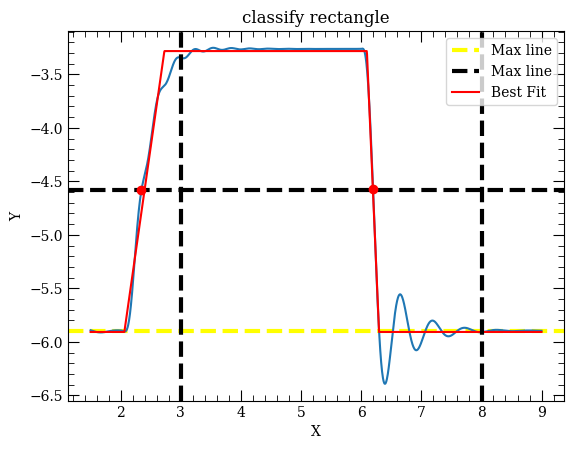

[ 195 1133]
Guessed Parameters:
amplitude: 3.1406566378119436
center1: 2.6248436848686953
sigma1: 1.0711606026320493
center2: 7.874531054606086
sigma2: 1.0711606026320493
c: -4.2266178792901075
midpoint: 5.249687369737391
[[Model]]
    (Model(rectangle, form='linear') + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 78
    # data points      = 1500
    # variables        = 6
    chi-square         = 14.7522136
    reduced chi-square = 0.00987431
    Akaike info crit   = -6920.74086
    Bayesian info crit = -6888.86154
    R-squared          = 0.99333491
[[Variables]]
    amplitude:  2.63563217 +/- 0.00575511 (0.22%) (init = 3.140657)
    center1:    2.39552087 +/- 0.00230133 (0.10%) (init = 2.624844)
    sigma1:     0.33609247 +/- 0.00383168 (1.14%) (init = 1.071161)
    center2:    7.19646466 +/- 0.00122994 (0.02%) (init = 7.874531)
    sigma2:     0.10145922 +/- 0.00213708 (2.11%) (init = 1.071161)
    c:         -5.91304719 +/- 0.004668

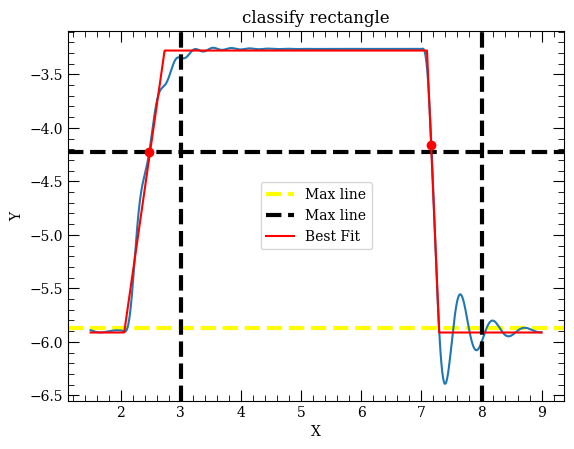

In [53]:
#For off resonant

data_cross_segment_width_off = [] 
for rabi in range(len(omegaC_list)):   
    im_chi_off_resonance_time = -1 * np.imag(data_chi_off_resonance[rabi]) 
    #print(omegaC_list[rabi]) 
    off_resonance_result = []
    for i in range(0,len(im_chi_off_resonance_time)):   
        #print(t_array[i]-t_array[0]) 
        dat = classify_rectangle(im_chi_off_resonance_time,i,300,1800)
        off_resonance_result.append(dat)   
        plt.show()
    data_cross_segment_width_off.append(off_resonance_result) 
data_cross_segment_width_off = np.array(data_cross_segment_width_off)

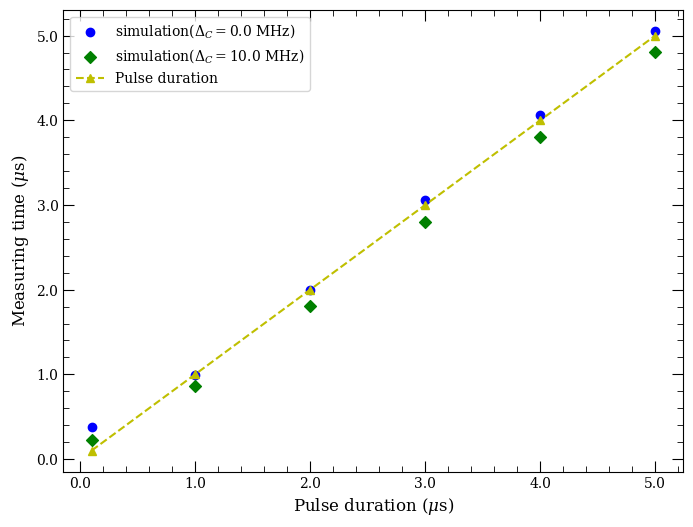

In [96]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker 

# Create a new figure
fig = plt.figure(figsize=(8, 6))  # Define size if needed

# Define font properties
title_font = {'family': 'serif', 'size': 14}
label_font = {'family': 'serif', 'size': 12}

# Define markers and colors
m = ['o', 'D', '^', 'o', '1']  # Marker types
color = ['blue', 'green', 'yellow', 'red', 'purple']  # Colors for markers

# Plot data
for i in range(len(omegaC_list)): 
    plt.scatter(
        t_array * 1e6,  # Convert to microseconds
        data_cross_segment_width_on[i], 
        marker=m[i % len(m)],  # Cycle through markers if needed
        color=color[i % len(color)],  # Cycle through colors if needed
        label=fr"simulation($\Delta_C = {dc_on_off[0] / 1e6:.1f}$ MHz)"
    )   

# Plot data
for i in range(len(omegaC_list)): 
    plt.scatter(
        t_array * 1e6,  # Convert to microseconds
        data_cross_segment_width_off[i], 
        marker=m[1],  # Cycle through markers if needed
        color=color[1],  # Cycle through colors if needed
        label=fr"simulation($\Delta_C = {dc_on_off[1] / 1e6:.1f}$ MHz)"
    ) 

# Add the pulse duration plot
plt.plot(t_array * 1e6, t_array * 1e6, '--y^', label='Pulse duration')

# Remove duplicate labels in the legend
handles, labels = plt.gca().get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
plt.legend(unique_labels.values(), unique_labels.keys())

# Configure labels and title
#plt.suptitle(r"$\Omega_{P}$ - " + f"{rabi12 / 1E6:.1f} MHz", **title_font)
plt.xlabel(r"Pulse duration ($\mu$s)", **label_font)
plt.ylabel(r"Measuring time ($\mu$s)", **label_font)

# Set tick formatter to display 1 decimal place on both axes
plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))


fig.savefig("simulation_width_measure_on_off.png", dpi=300, bbox_inches='tight') 
fig.savefig("simulation_width_measure_on_off.tiff", dpi=300, format='tiff', bbox_inches='tight')
# Show the plot
plt.show()



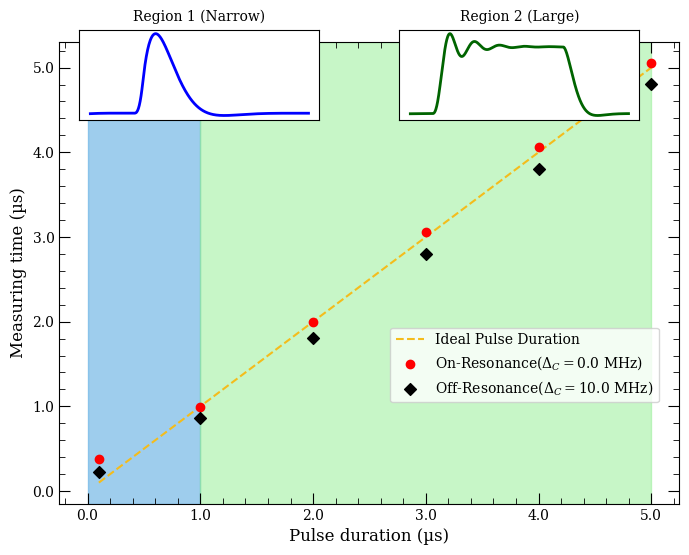

In [127]:
import numpy as np
import matplotlib.pyplot as plt

# Create a new figure
# Create Figure
fig, ax = plt.subplots(figsize=(8, 6))

# Define font properties
title_font = {'family': 'serif', 'size': 14}
label_font = {'family': 'serif', 'size': 12}

# Define markers and colors
m = ['o', 'D', '^', 'o', '1']  # Marker types
color = ['red', 'black', 'yellow', 'green', 'purple']  # Colors for markers

# Shade Region 1 (Light Blue) & Region 2 (Light Green)
ax.axvspan(0, 1, color="#5DADE2", alpha=0.6)  # Adjusted light blue
ax.axvspan(1, 5, color="#90EE90", alpha=0.5)  # Light green

# Dashed Line for Ideal Pulse Duration
ax.plot(t_array * 1e6, t_array * 1e6, '--',color = '#F4BC1C', label="Ideal Pulse Duration" ,zorder=1)

# Plot data
for i in range(len(omegaC_list)): 
    plt.scatter(
        t_array * 1e6,  # Convert to microseconds
        data_cross_segment_width_on[i], 
        marker=m[i % len(m)],  # Cycle through markers if needed
        color=color[i % len(color)],  # Cycle through colors if needed
        label=fr"On-Resonance($\Delta_C = {dc_on_off[0] / 1e6:.1f}$ MHz)"
    )   

# Plot data
for i in range(len(omegaC_list)): 
    plt.scatter(
        t_array * 1e6,  # Convert to microseconds
        data_cross_segment_width_off[i], 
        marker=m[1],  # Cycle through markers if needed
        color=color[1],  # Cycle through colors if needed
        label=fr"Off-Resonance($\Delta_C = {dc_on_off[1] / 1e6:.1f}$ MHz)"
    ) 



# Remove duplicate labels in the legend
handles, labels = ax.get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
ax.legend(unique_labels.values(), unique_labels.keys(), loc="center", bbox_to_anchor=(0.75, 0.3))

# Formatting
ax.set_xlabel("Pulse duration (µs)", fontsize=12)
ax.set_ylabel("Measuring time (µs)", fontsize=12)

# Set tick formatter to display 1 decimal place
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

# Grid Style
#ax.grid(True, linestyle="--", linewidth=0.5)

# Add Subplots (Gaussian in Region 1, Sine in Region 2)
# Gaussian Curve (Region 1)
left_inset = fig.add_axes([0.15, 0.75, 0.3, 0.15])  # [x, y, width, height]
x_region1 = np.arange(0, 500)
y_region1 = 10000 * np.imag(data_chi_on_resonance[0][0])[300:800]  
left_inset.plot(x_region1, y_region1, color="blue", linewidth=2)
left_inset.set_xticks([])
left_inset.set_yticks([])
left_inset.set_title("Region 1 (Narrow)", fontsize=10)

# Sine Wave (Region 2)
right_inset = fig.add_axes([0.55, 0.75, 0.3, 0.15])  
x_region2 = np.arange(0, 1000)
y_region2 = 10000 * np.imag(data_chi_on_resonance[0][3])[300:1300]  
right_inset.plot(x_region2, y_region2, color="darkgreen", linewidth=2)
right_inset.set_xticks([])
right_inset.set_yticks([])
right_inset.set_title("Region 2 (Large)", fontsize=10)

# Save and Show
plt.savefig("duration_compare_highlighted_regions.png", dpi=300, bbox_inches='tight')
plt.show()

# line width checking 

In [ ]:
# create list of delta_p values
deltalist = np.linspace(-200,200,401)
# empty list to save results
chi = [] # susceptibility

In [ ]:
#define Rabies frequency 
#E=1E3
deltaC = 0 # coupling field detuning  
omegaC_list = [10,20,50,100,200]
deltaRF = 0 
#For omegaP and OmagaC is 1 MHz
omegaP = 1E6 # Rabi freq. for probe
omegaC = 100E6 # Rabi freq. for control  
#omegaP_list = [(10*i)*1e6 for i in range(7)] 
deltaP0 = 1E6

In [ ]:
deltaP =0  
deltaC = 0 
omega = 0 
omegaP = 40E6 # Rabi freq. for probe
omegaC = 10E6 # Rabi freq. for control 
res=[]
for omegaP in deltalist:
    H = 1/2*Qobj([[0,omegaP,0,0],[omegaP,-2*(deltaP)*10**6,omegaC,0]
            ,[0,omegaC,-2*(deltaP+deltaC)*10**6,0],
                       [0,0,0,-2*(deltaP+deltaC+deltaRF)*10**6]])
    rho_ss = steadystate(H,collapse)  
    res.append(expect(sig_12.dag(),rho_ss)) 
Efield = E_from_Rabi(omegaP,abs(dipmat12))   
chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res]  
transmittance = [transmission(L,np.imag(i),lambda12) for i in chi] 

In [ ]:
omegaP = 0.5E6 
omegaC_list = np.array([5,10,25,50,100])*1e6 
omegaP_list = np.array([0.1,0.5,1,2,8])*1e6
chi_list=[] 
deltaP =0  
deltaC = 0 
omega = 0 
for omegaP in tqdm(omegaP_list) : 
    res=[]
    for deltaC in deltalist:
        H = 1/2*Qobj([[0,omegaP,0,0],[omegaP,-2*(deltaP)*10**6,omegaC,0]
               ,[0,omegaC,-2*(deltaP+deltaC)*10**6,omega],
                       [0,0,omega,-2*(deltaP+deltaC+deltaRF)*10**6]])
        rho_ss = steadystate(H,collapse)  
        res.append(expect(sig_12.dag(),rho_ss)) 
    Efield = E_from_Rabi(omegaP,abs(dipmat12))   
    print(Efield)
    chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res]  
    transmittance = [transmission(L,np.imag(i),lambda12) for i in chi] 
    print(transmittance)
    refraction = np.real(chi)
    absorption = 2*pi*np.imag(chi)/lambda12 
    chi_list.append(chi)

 20%|██        | 1/5 [00:00<00:03,  1.28it/s]

0.5096388822225328
[np.float64(2.5738226480040274e-29), np.float64(2.574048491143166e-29), np.float64(2.574277773083526e-29), np.float64(2.5745105640379386e-29), np.float64(2.5747469360215555e-29), np.float64(2.5749869629075333e-29), np.float64(2.575230720484854e-29), np.float64(2.5754782865186893e-29), np.float64(2.5757297408121856e-29), np.float64(2.575985165271055e-29), np.float64(2.5762446439705084e-29), np.float64(2.5765082632246163e-29), np.float64(2.5767761116582695e-29), np.float64(2.5770482802815814e-29), np.float64(2.5773248625680813e-29), np.float64(2.577605954534482e-29), np.float64(2.577891654824584e-29), np.float64(2.57818206479616e-29), np.float64(2.5784772886106074e-29), np.float64(2.57877743332746e-29), np.float64(2.5790826090007054e-29), np.float64(2.579392928780861e-29), np.float64(2.5797085090196415e-29), np.float64(2.580029469379389e-29), np.float64(2.580355932947172e-29), np.float64(2.580688026352679e-29), np.float64(2.58102587989184e-29), np.float64(2.58136962765

 40%|████      | 2/5 [00:01<00:02,  1.25it/s]

2.548194411112664
[np.float64(2.6190663372921254e-29), np.float64(2.619296772989686e-29), np.float64(2.619530716296201e-29), np.float64(2.619768238803911e-29), np.float64(2.620009413941337e-29), np.float64(2.620254317031249e-29), np.float64(2.6205030253492535e-29), np.float64(2.620755618184449e-29), np.float64(2.621012176903565e-29), np.float64(2.621272785016256e-29), np.float64(2.621537528242961e-29), np.float64(2.6218064945861225e-29), np.float64(2.6220797744032775e-29), np.float64(2.622357460482742e-29), np.float64(2.622639648123374e-29), np.float64(2.622926435215796e-29), np.float64(2.623217922328083e-29), np.float64(2.623514212793705e-29), np.float64(2.6238154128038846e-29), np.float64(2.624121631502485e-29), np.float64(2.6244329810853745e-29), np.float64(2.6247495769037545e-29), np.float64(2.625071537570684e-29), np.float64(2.625398985073161e-29), np.float64(2.625732044887757e-29), np.float64(2.626070846100907e-29), np.float64(2.626415521534868e-29), np.float64(2.626766207877694e

 60%|██████    | 3/5 [00:02<00:01,  1.23it/s]

5.096388822225328
[np.float64(2.7654787368379306e-29), np.float64(2.76572410421171e-29), np.float64(2.7659732028015277e-29), np.float64(2.7662261086781846e-29), np.float64(2.766482899862459e-29), np.float64(2.766743656384501e-29), np.float64(2.76700846034729e-29), np.float64(2.7672773959905905e-29), np.float64(2.767550549758674e-29), np.float64(2.767828010369524e-29), np.float64(2.768109868887428e-29), np.float64(2.768396218797544e-29), np.float64(2.768687156083625e-29), np.float64(2.768982779308913e-29), np.float64(2.769283189699736e-29), np.float64(2.769588491231818e-29), np.float64(2.7698987907216684e-29), np.float64(2.7702141979188946e-29), np.float64(2.770534825604361e-29), np.float64(2.7708607896910173e-29), np.float64(2.771192209329109e-29), np.float64(2.7715292070148987e-29), np.float64(2.7718719087046623e-29), np.float64(2.772220443932382e-29), np.float64(2.7725749459328957e-29), np.float64(2.772935551768852e-29), np.float64(2.773302402464532e-29), np.float64(2.773675643143157

 80%|████████  | 4/5 [00:03<00:00,  1.24it/s]

10.192777644450656
[np.float64(3.434601861179037e-29), np.float64(3.434916692596298e-29), np.float64(3.4352362936208784e-29), np.float64(3.4355607610801374e-29), np.float64(3.4358901942718294e-29), np.float64(3.436224695039955e-29), np.float64(3.436564367853465e-29), np.float64(3.436909319888086e-29), np.float64(3.437259661111056e-29), np.float64(3.437615504368702e-29), np.float64(3.4379769654772964e-29), np.float64(3.438344163317886e-29), np.float64(3.438717219933439e-29), np.float64(3.4390962606312615e-29), np.float64(3.4394814140878914e-29), np.float64(3.439872812458453e-29), np.float64(3.4402705914903705e-29), np.float64(3.4406748906409285e-29), np.float64(3.4410858532005374e-29), np.float64(3.441503626418987e-29), np.float64(3.44192836163788e-29), np.float64(3.4423602144283776e-29), np.float64(3.4427993447332976e-29), np.float64(3.4432459170160747e-29), np.float64(3.443700100414697e-29), np.float64(3.444162068902444e-29), np.float64(3.444632001454519e-29), np.float64(3.44511008222

100%|██████████| 5/5 [00:03<00:00,  1.26it/s]

40.771110577802624
[np.float64(1.9761067014291475e-27), np.float64(1.9763888858168246e-27), np.float64(1.9766751774147454e-27), np.float64(1.97696565569177e-27), np.float64(1.9772604020359663e-27), np.float64(1.977559499810705e-27), np.float64(1.977863034412077e-27), np.float64(1.9781710933282437e-27), np.float64(1.9784837662012124e-27), np.float64(1.9788011448904596e-27), np.float64(1.9791233235387674e-27), np.float64(1.9794503986404938e-27), np.float64(1.9797824691120857e-27), np.float64(1.9801196363651972e-27), np.float64(1.9804620043822165e-27), np.float64(1.980809679794671e-27), np.float64(1.9811627719643863e-27), np.float64(1.981521393067351e-27), np.float64(1.981885658180982e-27), np.float64(1.9822556853739654e-27), np.float64(1.9826315958004424e-27), np.float64(1.983013513796112e-27), np.float64(1.983401566979398e-27), np.float64(1.9837958863553582e-27), np.float64(1.984196606423831e-27), np.float64(1.984603865291719e-27), np.float64(1.9850178047889956e-27), np.float64(1.985438

<>:5: SyntaxWarning: invalid escape sequence '\O'
<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\c'
<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\O'
<>:5: SyntaxWarning: invalid escape sequence '\O'
<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\c'
<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\O'
C:\Users\beam_\AppData\Local\Temp\ipykernel_9860\977156379.py:5: SyntaxWarning: invalid escape sequence '\O'
  plt.plot(deltalist,-np.imag(chi_list[i]),label="$\Omega_{P}$-"+str(omegaP_list[i]/1E6)+" MHz")
C:\Users\beam_\AppData\Local\Temp\ipykernel_9860\977156379.py:7: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("$\Delta_C$"+" MHz", fontdict = font2)
C:\Users\beam_\AppData\Local\Temp\ipykernel_9860\977156379.py:8: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel("-Im[$\chi$

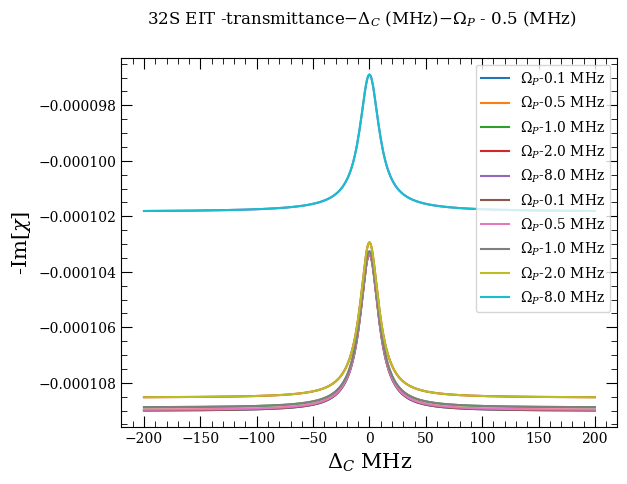

In [ ]:
font1 = {'family': 'serif', 'color': 'black', 'fontsize': 20}
font2 = {'family': 'serif', 'color': 'black', 'fontsize': 15}
for i in range(len(chi_list)):  
    #chi_list[0] = np.zeros(len(chi_list[0]))
    plt.plot(deltalist,-np.imag(chi_list[i]),label="$\Omega_{P}$-"+str(omegaP_list[i]/1E6)+" MHz") 
    #plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    plt.xlabel("$\Delta_C$"+" MHz", fontdict = font2)     
    plt.ylabel("-Im[$\chi$]", fontdict = font2)
plt.suptitle('32S EIT -' + r"transmittance" + "$ - \Delta_C$ (MHz)"+"$ - \Omega_P$ - 0.5 (MHz)", fontdict = font2) 
#    plt.yticks([])  
#plt.xlim(-5,5)  
#plt.xlim(-10,10)
# check imaginary path of chi  
plt.legend()
plt.show()